## Goal: Predict day-ahead GB wholesale power prices so a Battery Energy Storage System (BESS) can perform arbitrage.

### Key constraint: Day-ahead auction closes at 10:00 AM - So the model must only use information available before 10am. 
So we can use these for the forecast -

- Historical prices up to D‑1 09:30 (or last available settlement period).

- Day‑ahead demand forecast for D (from Elexon)

  **Why?** Price is strongly driven by demand—higher demand → more expensive marginal plants → higher prices.

- Day‑ahead wind forecast for D (from NESO).

  **Why?** Wind is low marginal cost; high wind → lower prices, more negative price risk.

- Calendar info (weekday/weekend, holidays, season).

    **Why?** Captures systematic patterns (e.g., weekday evening peaks, lower weekend demand).

In [1]:
import pandas as pd
import numpy as np
import csv
import requests
from datetime import datetime, timedelta
import glob
import os
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

## 1. Data Collection

#### 1.1 Market index price data from Elexon

In [2]:
### We are downloading data for the given period between start_date and end_date

def get_price_data(start_date, end_date, source_url):
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)
    
    date_ranges = []
    
    current = start_date
    
    while current <= end_date:
        week_end = current + timedelta(days=6)
        if week_end > end_date:
            week_end = end_date
        date_ranges.append((current, week_end))
        current = week_end + timedelta(days=1)
        
    all_price_data = []
    
    url = source_url
    
    for start, end in date_ranges:
        params = {
            "from": start.strftime("%Y-%m-%d"),
            "to": end.strftime("%Y-%m-%d"),
            "format": "json"
        }
        try:
            r = requests.get(url, params=params)
            r.raise_for_status()
            data = r.json()
            if "data" in data:
                df = pd.json_normalize(data["data"]) #Normalize semi-structured JSON data into a flat table
                all_price_data.append(df)
            print(f"Downloaded {start.date()} to {end.date()}")
        except Exception as e:
            print(f"Error for {start} to {end}: {e}")
    price_df = pd.concat(all_price_data, ignore_index=True)
    return price_df

price_df = get_price_data("2023-01-01", "2024-12-31", source_url="https://data.elexon.co.uk/bmrs/api/v1/balancing/pricing/market-index")

Downloaded 2023-01-01 to 2023-01-07
Downloaded 2023-01-08 to 2023-01-14
Downloaded 2023-01-15 to 2023-01-21
Downloaded 2023-01-22 to 2023-01-28
Downloaded 2023-01-29 to 2023-02-04
Downloaded 2023-02-05 to 2023-02-11
Downloaded 2023-02-12 to 2023-02-18
Downloaded 2023-02-19 to 2023-02-25
Downloaded 2023-02-26 to 2023-03-04
Downloaded 2023-03-05 to 2023-03-11
Downloaded 2023-03-12 to 2023-03-18
Downloaded 2023-03-19 to 2023-03-25
Downloaded 2023-03-26 to 2023-04-01
Downloaded 2023-04-02 to 2023-04-08
Downloaded 2023-04-09 to 2023-04-15
Downloaded 2023-04-16 to 2023-04-22
Downloaded 2023-04-23 to 2023-04-29
Downloaded 2023-04-30 to 2023-05-06
Downloaded 2023-05-07 to 2023-05-13
Downloaded 2023-05-14 to 2023-05-20
Downloaded 2023-05-21 to 2023-05-27
Downloaded 2023-05-28 to 2023-06-03
Downloaded 2023-06-04 to 2023-06-10
Downloaded 2023-06-11 to 2023-06-17
Downloaded 2023-06-18 to 2023-06-24
Downloaded 2023-06-25 to 2023-07-01
Downloaded 2023-07-02 to 2023-07-08
Downloaded 2023-07-09 to 202

In [3]:
print("Total rows:", len(price_df))
price_df.head(10)

Total rows: 60219


,startTime,dataProvider,settlementDate,settlementPeriod,price,volume
0,2023-01-07T00:00:00Z,APXMIDP,2023-01-07,1,3.22,853.05
1,2023-01-07T00:00:00Z,N2EXMIDP,2023-01-07,1,0.00,0.00
2,2023-01-06T23:30:00Z,APXMIDP,2023-01-06,48,20.32,789.90
3,2023-01-06T23:30:00Z,N2EXMIDP,2023-01-06,48,0.00,0.00
4,2023-01-06T23:00:00Z,APXMIDP,2023-01-06,47,71.31,1048.30
5,2023-01-06T23:00:00Z,N2EXMIDP,2023-01-06,47,0.00,0.00
6,2023-01-06T22:30:00Z,APXMIDP,2023-01-06,46,72.92,1698.70
7,2023-01-06T22:30:00Z,N2EXMIDP,2023-01-06,46,0.00,0.00
8,2023-01-06T22:00:00Z,APXMIDP,2023-01-06,45,83.47,1765.10
9,2023-01-06T22:00:00Z,N2EXMIDP,2023-01-06,45,0.00,0.00


#### Preprocessing of Market Index Price:
- Market Index Price endpoint returns multiple entries for one settlement period provided by two dataProvider values. The forecast given by N2EXMDP show almost all 0 values, hence filtering those out from the data and keeping only forecast provided by APXMIDP.
- From the initial analysis we can see some duplicate records and some missing values. Taking care of those are also important for the forecast model. Hence rebuilding the timeline for every 30 minutes. Also, filling missing prices with forward fill.
- At the end we are only taking two reuired columns from this data.

In [4]:
def process_mpi(price_df):
    price_df = price_df[price_df['dataProvider'] == 'APXMIDP'].copy()
    price_df["settlementDate"] = pd.to_datetime(price_df["settlementDate"])
    price_df["timestamp"] = (
        price_df["settlementDate"]
        + pd.to_timedelta((price_df["settlementPeriod"] - 1) * 30, unit="m")
    ) # timestamp construction formula assumes 48 SPs, which is correct for the vast majority of days.
    # SP numbering starts at 1 but the clock starts at 0, you subtract 1 to align them before multiplying.
    price_df = price_df.drop_duplicates(subset="timestamp")
    price_df = price_df.sort_values("timestamp")
    price_df = price_df.reset_index(drop=True)
    full_index = pd.date_range(
        start=price_df["timestamp"].min(),
        end=price_df["timestamp"].max(),
        freq="30min"
    )
    price_df = (
        price_df
        .set_index("timestamp")
        .reindex(full_index)
    )
    price_df.index.name = "timestamp"
    price_df = price_df.reset_index()
    price_df["price"] = price_df["price"].ffill()
    
    price_df["date"] = price_df["timestamp"].dt.date
    
    price_df["settlementPeriod"] = (
        price_df["timestamp"].dt.hour * 2
        + price_df["timestamp"].dt.minute // 30
        + 1
    )
    price_df = price_df[["timestamp", "price"]]
    return price_df

In [5]:
price_df = process_mpi(price_df)
print(f"Shape of preprocessed price_df:{price_df.shape}")
print(f"Price mean after preprocessing: £{price_df['price'].mean():.1f}/MWh")
print(f"Price range: £{price_df['price'].min():.1f} to £{price_df['price'].max():.1f}")

Shape of preprocessed price_df:(35041, 2)
Price mean after preprocessing: £81.7/MWh
Price range: £-77.3 to £605.2


#### 1.2 Demand Forecast in downloaded locally for the same period using the link below:
https://www.neso.energy/data-portal/historic-demand-data?page=1

In [6]:
folder_path = r"C:\Users\olive\Documents\workspace\BESSPriceForecasting\data"
pattern = os.path.join(folder_path, "demanddata_*.csv")  # adjust pattern as needed
file_list = glob.glob(pattern)
demand_df = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)

In [7]:
demand_df

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SCOTTISH_TRANSFER
0,01-JAN-2021,1,28354,28969,26130,1158,6527,0,13471,0,...,-1,0,215,203,999,0,0,0,0,NaN
1,01-JAN-2021,2,28501,29114,26281,1208,6527,0,13471,0,...,-1,0,359,203,999,0,0,0,0,NaN
2,01-JAN-2021,3,27759,28376,25557,1202,6527,0,13471,0,...,-1,0,362,202,999,0,0,0,0,NaN
3,01-JAN-2021,4,26912,27749,24792,1226,6527,0,13471,0,...,-1,0,361,203,1000,0,0,0,0,NaN
4,01-JAN-2021,5,26004,27178,23933,1193,6527,0,13471,0,...,-1,0,304,203,1000,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70123,31-DEC-2024,44,23565,28298,22360,5685,6606,0,18720,0,...,-1028,1,-301,-521,885,1368,0,1015,0,5029.0
70124,31-DEC-2024,45,22463,27216,21344,5668,6606,0,18720,0,...,-1028,0,-300,-523,828,994,0,145,0,5240.0
70125,31-DEC-2024,46,21753,26685,20714,5650,6606,0,18720,0,...,-1028,0,-300,-530,787,918,0,79,0,5301.0
70126,31-DEC-2024,47,21000,25967,19961,5551,6606,0,18720,0,...,-1028,1,-300,-462,-274,546,0,2,0,5531.0


In [8]:
def process_demand_data(demand_df):
    demand_df["SETTLEMENT_DATE"] = pd.to_datetime(demand_df["SETTLEMENT_DATE"])
    demand_df["timestamp"] = (
        demand_df["SETTLEMENT_DATE"]
        + pd.to_timedelta((demand_df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")
    )
    demand_df = demand_df.rename(columns={
    "ND": "demand",
    "EMBEDDED_WIND_GENERATION": "wind_gen",
    "EMBEDDED_SOLAR_GENERATION": "solar_gen"
    })
    interconnectors = [
    "IFA_FLOW",
    "IFA2_FLOW",
    "BRITNED_FLOW",
    "MOYLE_FLOW",
    "EAST_WEST_FLOW",
    "NEMO_FLOW",
    "NSL_FLOW",
    "ELECLINK_FLOW",
    "VIKING_FLOW",
    "GREENLINK_FLOW"
    ]

    demand_df["interconnector_flow"] = demand_df[interconnectors].sum(axis=1)
    demand_df["net_demand"] = (
        demand_df["demand"]
        - demand_df["wind_gen"]
        - demand_df["solar_gen"]
    )
    demand_df = demand_df[[
        "timestamp",
        "demand",
        "wind_gen",
        "solar_gen",
        "net_demand",
        "interconnector_flow"
    ]]
    return demand_df

In [9]:
demand_df = process_demand_data(demand_df)

C:\Users\olive\AppData\Local\Temp\ipykernel_49496\3714906352.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  demand_df["SETTLEMENT_DATE"] = pd.to_datetime(demand_df["SETTLEMENT_DATE"])


#### Wind forecast data is downloaded locally for the whole period from:
https://www.neso.energy/data-portal/day-ahead-wind-forecast/historic_day_ahead_wind_forecasts

In [10]:
wind_df = pd.read_csv(r"C:\Users\olive\Documents\workspace\BESSPriceForecasting\data\archive_1dayaheadwind.csv")
def process_wind_forecast(wind_df):
    wind_df["timestamp"] = pd.to_datetime(wind_df["Datetime_GMT"]).dt.tz_localize(None)
    wind_df = wind_df.drop_duplicates(subset="timestamp")
    wind_df = wind_df.rename(columns={"Incentive_forecast": "wind_forecast"})
    print(wind_df.columns)
    wind_df = wind_df[["timestamp", "wind_forecast"]]
    return wind_df
wind_df = process_wind_forecast(wind_df)

Index(['Datetime_GMT', 'Date', 'Settlement_period', 'Capacity',
       'wind_forecast', 'Forecast_Timestamp', 'timestamp'],
      dtype='str')


In [11]:
wind_df

,timestamp,wind_forecast
0,2018-04-18 23:00:00,7632
1,2018-04-18 23:30:00,7532
2,2018-04-19 00:00:00,7375
3,2018-04-19 00:30:00,7159
4,2018-04-19 01:00:00,6938
...,...,...
138087,2026-03-06 21:30:00,5301
138088,2026-03-06 22:00:00,5371
138089,2026-03-06 22:30:00,5408
138090,2026-03-06 23:00:00,5430


## 2. Time alignment and resampling

In [12]:
full_range = pd.date_range(
    start=price_df.timestamp.min(),
    end=price_df.timestamp.max(),
    freq="30min"
)

base_df = pd.DataFrame({'timestamp':full_range})
df = base_df.merge(price_df, on='timestamp', how='left')
df = price_df.merge(demand_df, on="timestamp")
df = df.merge(wind_df, on="timestamp")

In [13]:
df = df.sort_values('timestamp')
df['demand'] = df['demand'].interpolate()
df['wind_forecast'] = df['wind_forecast'].interpolate()

In [14]:
df.head()

,timestamp,price,demand,wind_gen,solar_gen,net_demand,interconnector_flow,wind_forecast
0,2023-01-01 00:00:00,62.48,21043,2815,0,18228,1122,8479
1,2023-01-01 00:30:00,103.42,21756,2793,0,18963,1030,8699
2,2023-01-01 01:00:00,122.10,21348,2773,0,18575,642,8857
3,2023-01-01 01:30:00,52.75,20586,2753,0,17833,601,8952
4,2023-01-01 02:00:00,33.50,19781,2712,0,17069,233,9030


## 3. Feature Engineering

Every feature must pass two tests:
(1) It should causally influence price, not just correlate
(2) Available at 10:00 D-1.
As my features for training I am using 
(1) Temporal features (2)Lagged Features and (3)Supply Demand Features


- Why cyclical encoding?
Raw hour 0-23 has an artificial discontinuity: hour 23 and hour 0 are numerically far apart but represent consecutive settlement periods. Encoding as `sin(2*pi*h/24)` and `cos(2*pi*h/24)` wraps time into a circle — midnight is adjacent to 23:30 as it should be. Same logic applies to day-of-week and month.



In [15]:
def add_seasonality(df):
    """
    Captures systematic patterns (e.g., weekday evening peaks, lower weekend prices).
    Decomposed hour, day of week, month feature using sine and cosine transformations to preserve the cyclical nature of the 24-hour clock
    and the periodic structure of weekly trends.
    """
    df["hour"]       = df["timestamp"].dt.hour
    df["day_of_week"]= df["timestamp"].dt.dayofweek
    df["month"]      = df["timestamp"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["is_winter"]  = df["month"].isin([11,12,1,2,3]).astype(int)

    df["hour_sin"]   = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"]   = np.cos(2*np.pi*df["hour"]/24)
    df["dow_sin"]    = np.sin(2*np.pi*df["day_of_week"]/7)
    df["dow_cos"]    = np.cos(2*np.pi*df["day_of_week"]/7)
    df["month_sin"]  = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"]  = np.cos(2*np.pi*df["month"]/12)
    return df

def add_lagged_features(df):
    """
    Prices and system conditions have strong daily patterns. Lagged features help the model learn “similar days” behavior.
    """
    df["price_lag_336"]      = df["price"].shift(336)   # D-7 
    df["price_lag_672"]      = df["price"].shift(672)   # D-14 

    df["price_roll_mean_48"] = df["price"].shift(48).rolling(48).mean() # D-2
    df["price_roll_std_48"]  = df["price"].shift(48).rolling(48).std() # D-2
    df["demand_roll_mean_48"]= df["demand"].shift(1).rolling(48).mean() # D-2
    return df

def add_diff_and_netdemand(df):
    """
    Supply demand features
    """
    df["net_demand"]          = df["demand"] - df["wind_forecast"]
    df["wind_share"]          = df["wind_forecast"] / (df["demand"] + 1e-6)
    df["demand_change"]       = df["demand"].diff()
    df["wind_change"]         = df["wind_forecast"].diff()
    df["net_demand_change"]   = df["net_demand"].diff()
    df["net_demand_zscore"]   = (
        (df["net_demand"] - df["net_demand"].rolling(336).mean()) /
        (df["net_demand"].rolling(336).std() + 1e-6)
    )
    df["wind_zscore"]         = (
        (df["wind_forecast"] - df["wind_forecast"].rolling(336).mean()) /
        (df["wind_forecast"].rolling(336).std() + 1e-6)
    )
    df["tightness_x_demand"]  = df["net_demand_zscore"] * df["net_demand"]
    return df

In [16]:
df = add_seasonality(df)
df = add_lagged_features(df)
df = add_diff_and_netdemand(df)

In [17]:
features = [
'demand',
'wind_gen',
'solar_gen',
'net_demand',
'interconnector_flow',
'wind_forecast',
'hour',
'day_of_week',
'month',
'is_weekend',
'is_winter',
'hour_sin',
'hour_cos',
'dow_sin',
'dow_cos',
'month_sin',
'month_cos',
'price_lag_336',
'price_lag_672',
'price_roll_mean_48',
'price_roll_std_48',
'demand_roll_mean_48',
'wind_share',
'demand_change',
'wind_change',
'net_demand_change',
'net_demand_zscore',
'wind_zscore',
'tightness_x_demand'
]

target = "price"

## 4. Model Training

I use a hard temporal cut for Train-Test split: everything before the split date = training; everything after = unseen test. This is the only valid evaluation methodology for time-series forecasting.

**Why not random k-fold?**

Random cross-validation on a time series allows a January 2024 row to be in the training set while a December 2023 row is in the test set. The model would be "predicting" data it has already seen, leading to optimistic metrics that won't hold in production.

In [18]:
df = df.dropna(subset=features).reset_index(drop=True)
train_size = int(len(df)*0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]
print(f"Train size: {len(train)}")
print(f"Test size:  {len(test)}")
print(f"Train date range: {train['timestamp'].min()} → {train['timestamp'].max()}")
print(f"Test date range:  {test['timestamp'].min()} → {test['timestamp'].max()}")
print(f"\nNaNs in train features: {train[features].isna().sum().sum()}")
print(f"NaNs in test features:  {test[features].isna().sum().sum()}")
print(f"\nTrain price stats: mean={train['price'].mean():.1f}, std={train['price'].std():.1f}")
print(f"Test price stats:  mean={test['price'].mean():.1f}, std={test['price'].std():.1f}")

Train size: 27495
Test size:  6874
Train date range: 2023-01-15 00:00:00 → 2024-08-09 20:00:00
Test date range:  2024-08-09 20:30:00 → 2024-12-31 00:00:00

NaNs in train features: 0
NaNs in test features:  0

Train price stats: mean=81.3, std=36.5
Test price stats:  mean=80.5, std=36.8


#### Naive Baseline
- A dummy regressor predicts the mean values 
- The naive D-7 persistence baseline — just predict last week's same SP price

In [19]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(train[features], train['price'])
dummy_pred = dummy.predict(test[features])
print(f"Dummy mean MAE: {mean_absolute_error(test['price'], dummy_pred):.3f}")

# Naive lag baseline — predict D-7 same SP
lag_mae = mean_absolute_error(
    test['price'].values, 
    test['price_lag_336'].values
)
print(f"Naive lag-336 MAE: {lag_mae:.3f}")

Dummy mean MAE: 23.583
Naive lag-336 MAE: 28.790


#### Using XGBRegressor as the forecasting model because
- Handles non‑linear relationships (e.g., price vs demand is not linear).
- Handles interactions (e.g., high demand + low wind → very high prices).
- Reasonable performance without heavy feature scaling.

In [20]:
model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=1,
    early_stopping_rounds=50,
    eval_metric='mae',
    random_state=42
)


val_size = int(len(train) * 0.15)
X_tr  = train[features].iloc[:-val_size]
y_tr  = train['price'].iloc[:-val_size]
X_val = train[features].iloc[-val_size:]
y_val = train['price'].iloc[-val_size:]

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-mae:18.13892
[100]	validation_0-mae:11.91408
[155]	validation_0-mae:11.99412
Best iteration: 105


In [21]:
preds = model.predict(test[features])

In [22]:
def evaluate_model(model, test):
    X_test = test[features]
    y_test = test[target]
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return mae, rmse, y_test, y_pred

mae, rmse, y_test, y_pred = evaluate_model(model, test)
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 14.987934670684416
RMSE: 24.119155852940295


- The naive D-7 persistence baseline — just predict last week's same SP price — gives MAE of £28.79. The dummy mean predictor gives £23.58. My XGBoost model gives £14.99 — 47.9% better than the naive baseline.

 #### The model is evaluated on the held-out test set (Aug–Dec 2024). All predictions use only information available at 10:00 D-1.

In [23]:
# Predictions on test set
test = test.copy()
test['predicted_price'] = model.predict(test[features])
test['residual'] = test['price'] - test['predicted_price']
test['abs_error'] = np.abs(test['residual'])

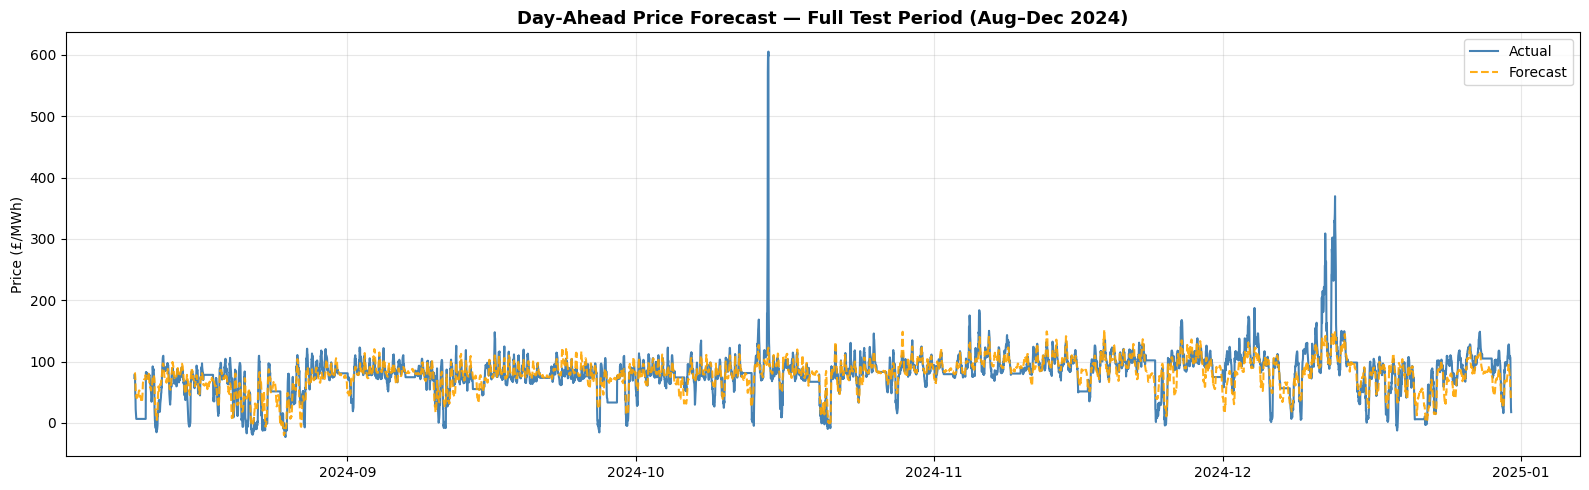

In [24]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(test['timestamp'], test['price'],
        label='Actual',color='steelblue')
ax.plot(test['timestamp'], test['predicted_price'],
        label='Forecast', alpha=0.9, 
        color='orange', linestyle='--')

ax.set_title('Day-Ahead Price Forecast — Full Test Period (Aug–Dec 2024)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (£/MWh)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### A sample week shows the model captures the intraday double-peak structure and weekday/weekend differences.

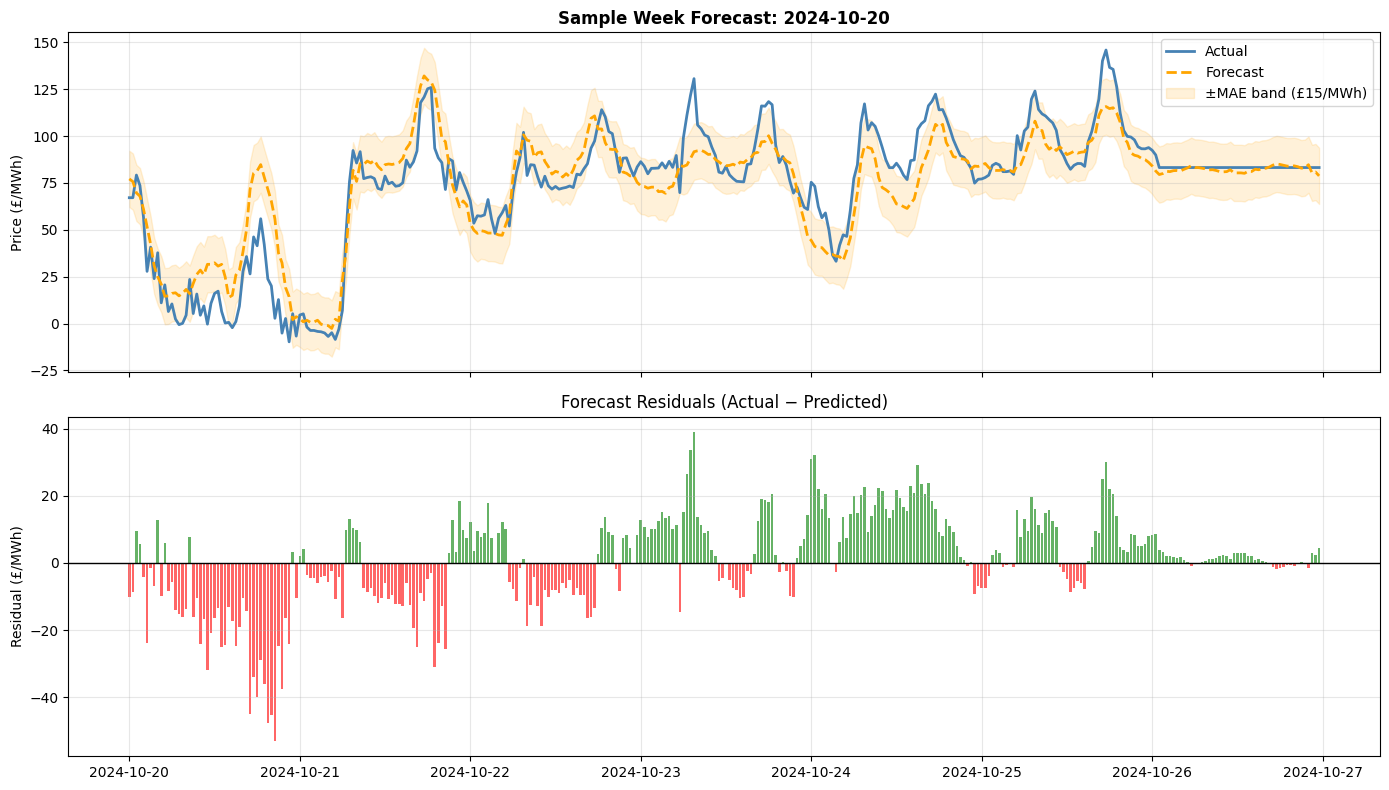

In [25]:
week_start = test['timestamp'].iloc[len(test)//2].normalize()
week_mask  = (
    (test['timestamp'] >= week_start) & 
    (test['timestamp'] < week_start + pd.Timedelta(days=7))
)
week = test[week_mask]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price forecast
axes[0].plot(week['timestamp'], week['price'],
             label='Actual', lw=2, color='steelblue')
axes[0].plot(week['timestamp'], week['predicted_price'],
             label='Forecast', lw=2, color='orange', linestyle='--')
axes[0].fill_between(week['timestamp'],
                     week['predicted_price'] - 15,
                     week['predicted_price'] + 15,
                     alpha=0.15, color='orange',
                     label='±MAE band (£15/MWh)')
axes[0].set_ylabel('Price (£/MWh)')
axes[0].set_title(f'Sample Week Forecast: {week_start.date()}',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
axes[1].bar(week['timestamp'], week['residual'],
            color=np.where(week['residual'] > 0, 'green', 'red'),
            alpha=0.6, width=0.015)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_ylabel('Residual (£/MWh)')
axes[1].set_title('Forecast Residuals (Actual − Predicted)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Averaged across the test period, the forecast tracks the actual intraday profile closely, correctly identifying the morning and evening demand peaks that drive BESS dispatch timing.

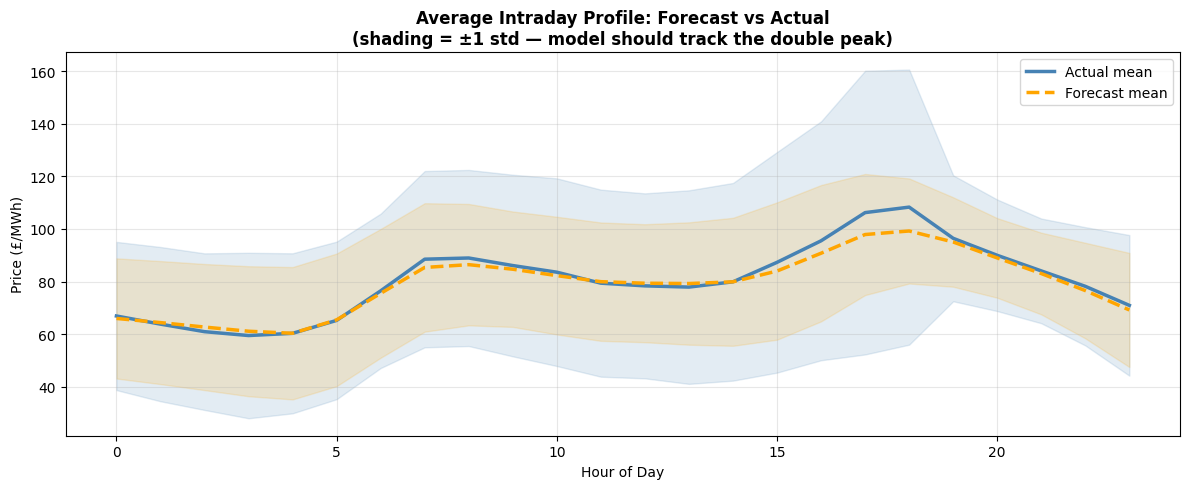

In [26]:
hourly = test.groupby(test['timestamp'].dt.hour).agg(
    actual_mean    = ('price', 'mean'),
    predicted_mean = ('predicted_price', 'mean'),
    actual_std     = ('price', 'std'),
    predicted_std  = ('predicted_price', 'std')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(hourly['timestamp'],
                hourly['actual_mean'] - hourly['actual_std'],
                hourly['actual_mean'] + hourly['actual_std'],
                alpha=0.15, color='steelblue')
ax.fill_between(hourly['timestamp'],
                hourly['predicted_mean'] - hourly['predicted_std'],
                hourly['predicted_mean'] + hourly['predicted_std'],
                alpha=0.15, color='orange')
ax.plot(hourly['timestamp'], hourly['actual_mean'],
        color='steelblue', lw=2.5, label='Actual mean')
ax.plot(hourly['timestamp'], hourly['predicted_mean'],
        color='orange', lw=2.5, linestyle='--', label='Forecast mean')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Price (£/MWh)')
ax.set_title('Average Intraday Profile: Forecast vs Actual\n'
             '(shading = ±1 std — model should track the double peak)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### A significant amount of error is contributed by <1% of observations where prices exceed £200/MWh — spike events driven by unscheduled outages not captured in available forecast data

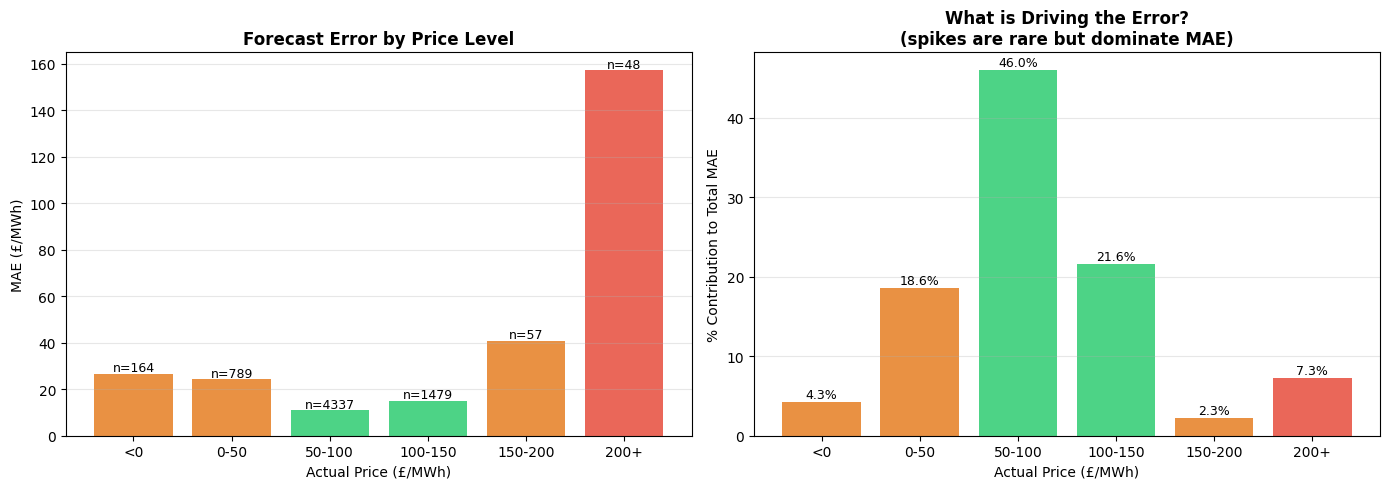

In [27]:
bucket_stats = test.groupby(
    pd.cut(test['price'],
           bins=[-100, 0, 50, 100, 150, 200, 800],
           labels=['<0', '0-50', '50-100', '100-150', '150-200', '200+'])
, observed=True)['abs_error'].agg(['mean','count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if m < 20 else '#e67e22' if m < 50 else '#e74c3c'
          for m in bucket_stats['mean']]

axes[0].bar(bucket_stats.index, bucket_stats['mean'],
            color=colors, alpha=0.85)
axes[0].set_xlabel('Actual Price (£/MWh)')
axes[0].set_ylabel('MAE (£/MWh)')
axes[0].set_title('Forecast Error by Price Level',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, (m, c) in enumerate(zip(bucket_stats['mean'], bucket_stats['count'])):
    axes[0].text(i, m + 1, f'n={c}', ha='center', fontsize=9)

# MAE contribution
contrib = bucket_stats['mean'] * bucket_stats['count']
pct     = contrib / contrib.sum() * 100
axes[1].bar(bucket_stats.index, pct, color=colors, alpha=0.85)
axes[1].set_xlabel('Actual Price (£/MWh)')
axes[1].set_ylabel('% Contribution to Total MAE')
axes[1].set_title('What is Driving the Error?\n'
                  '(spikes are rare but dominate MAE)',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, p in enumerate(pct):
    axes[1].text(i, p + 0.5, f'{p:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Day-Ahead Price Forecast

A 48-SP price vector for the delivery day, produced at 10:00 D-1 using only information available at that moment.

The `forecast_day_ahead()` function simulates tomorrow's price curve - it takes all information available at 10:00 D-1 (demand forecast, wind forecast, historical prices via D-7 lags and rolling means) and produces a 48-SP price vector for the delivery day. This is the output a BESS operator would receive each morning to plan their charge/discharge schedule

In [28]:
def forecast_day_ahead(model, df, features, forecast_date):
    """
    Simulates what happens at 10:00 on D-1.
    """
    forecast_date = pd.Timestamp(forecast_date)
    day_mask = df['timestamp'].dt.date == forecast_date.date()
    day_df   = df[day_mask].copy()
    
    if len(day_df) == 0:
        raise ValueError(f"No data found for {forecast_date.date()}")
    if len(day_df) < 48:
        print(f"Warning: only {len(day_df)} SPs found for {forecast_date.date()}, expected 48")
    missing = day_df[features].isna().sum()
    if missing.sum() > 0:
        print("Warning: missing features:")
        print(missing[missing > 0])
    
    # Produce the forecast
    day_df['predicted_price'] = model.predict(day_df[features])
    
    return day_df[['timestamp', 'predicted_price', 'price',
                   'net_demand', 'wind_forecast', 'demand']].reset_index(drop=True)


def forecast_multiple_days(model, df, features, start_date, end_date):
    """
    Rolls the forecast forward day by day.
    """
    dates   = pd.date_range(start=start_date, end=end_date, freq='D')
    results = []
    
    for date in dates:
        try:
            day_forecast = forecast_day_ahead(model, df, features, date)
            results.append(day_forecast)
        except ValueError:
            continue
    
    if not results:
        raise ValueError("No forecasts generated — check date range")
        
    return pd.concat(results, ignore_index=True)

In [29]:
# Forecast every day in the test set
test_start = test['timestamp'].min().date()
test_end   = test['timestamp'].max().date()

print(f"Producing day-ahead forecasts: {test_start} to {test_end}")
forecast_df = forecast_multiple_days(model, df, features, test_start, test_end)

# Evaluate
mae  = mean_absolute_error(forecast_df['price'], forecast_df['predicted_price'])
rmse = np.sqrt(np.mean((forecast_df['price'] - forecast_df['predicted_price'])**2))

print(f"\nForecast evaluation:")
print(f"  Periods forecast : {len(forecast_df)} SPs")
print(f"  Days forecast    : {forecast_df['timestamp'].dt.date.nunique()}")
print(f"  MAE              : £{mae:.2f}/MWh")
print(f"  RMSE             : £{rmse:.2f}/MWh")



Producing day-ahead forecasts: 2024-08-09 to 2024-12-31

Forecast evaluation:
  Periods forecast : 6915 SPs
  Days forecast    : 145
  MAE              : £15.02/MWh
  RMSE             : £24.12/MWh


Last full day: 2024-12-30
SPs available: 48
Forecast rows: 48


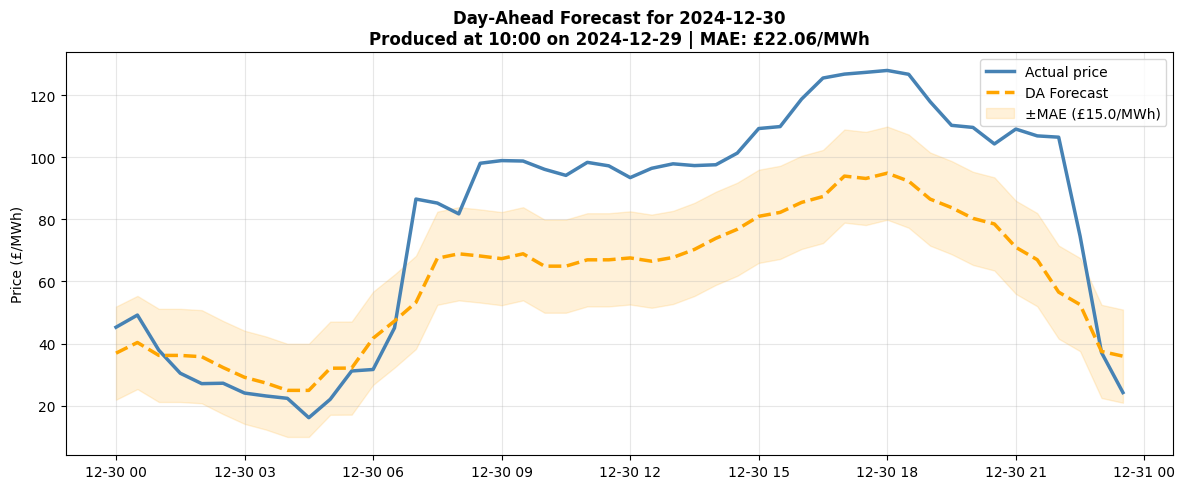

In [30]:
# Taking last date that has all 48 SPs and forecasting for that day
sp_counts = df.groupby(df['timestamp'].dt.date)['timestamp'].count()
full_days  = sp_counts[sp_counts == 48].index

last_full_day = pd.Timestamp(full_days[-1])
print(f"Last full day: {last_full_day.date()}")
print(f"SPs available: {sp_counts[full_days[-1]]}")
one_day = forecast_day_ahead(model, df, features, last_full_day)
print(f"Forecast rows: {len(one_day)}")


fig, ax = plt.subplots(figsize=(12, 5))

# Forecast vs actual
ax.plot(one_day['timestamp'], one_day['price'],
             color='steelblue', lw=2.5, label='Actual price')
ax.plot(one_day['timestamp'], one_day['predicted_price'],
             color='orange', lw=2.5, linestyle='--', label='DA Forecast')
ax.fill_between(one_day['timestamp'],
                     one_day['predicted_price'] - mae,
                     one_day['predicted_price'] + mae,
                     alpha=0.15, color='orange', label=f'±MAE (£{mae:.1f}/MWh)')
ax.set_ylabel('Price (£/MWh)')
ax.set_title(
    f'Day-Ahead Forecast for {last_full_day.date()}\n'
    f'Produced at 10:00 on {(last_full_day - pd.Timedelta(days=1)).date()} | '
    f'MAE: £{mean_absolute_error(one_day["price"], one_day["predicted_price"]):.2f}/MWh',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The single-day forecast MAE of £22 is higher than the backtest MAE of £15 as the backtest MAE is an average across many days including easy and hard days. Any specific single day will vary around that average. £22 on one day doesn't contradict £15 as the average

## 6. How forecast model can be used by BESS Optimizers?

The forecast is consumed by a greedy BESS Optimier. The battery charges during the cheapest forecast SPs and discharges during the most expensive, subject to SoC constraints.

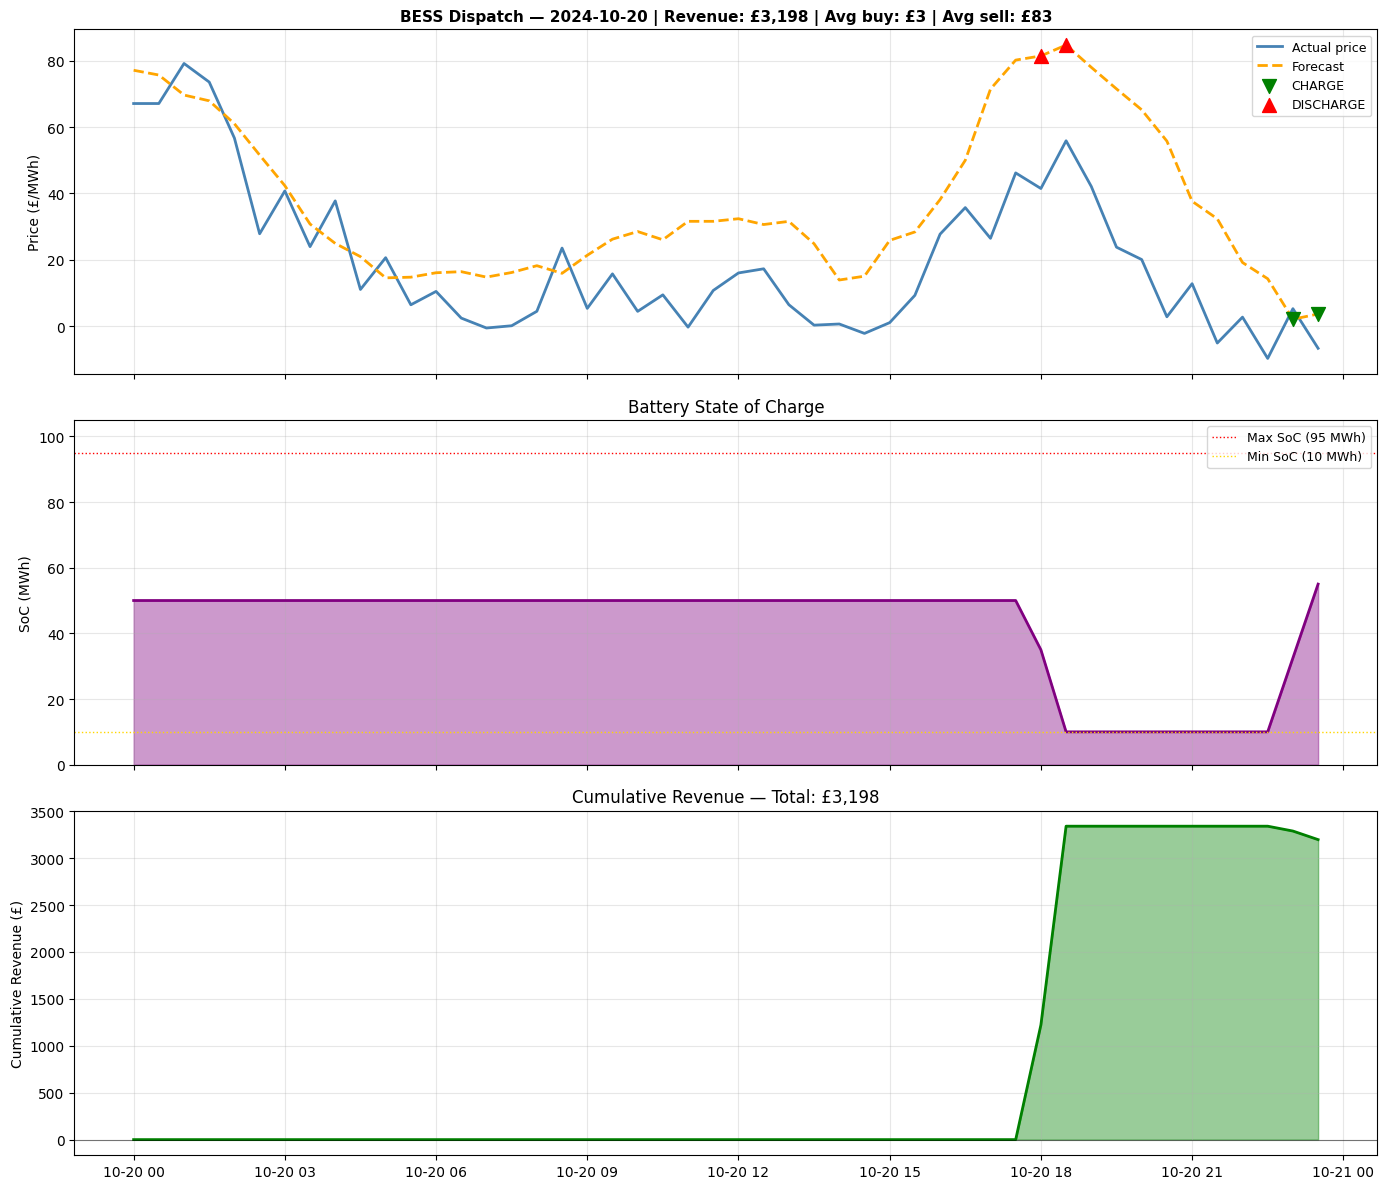

In [31]:
# Taking one day from test set
day_start = test['timestamp'].iloc[len(test)//2].normalize()
day_mask  = test['timestamp'].dt.date == day_start.date()
day       = test[day_mask].copy().reset_index(drop=True)

# Simple greedy dispatch
cap_mwh   = 100
power_mw  = 50                     
eta       = 0.90
soc_min   = cap_mwh * 0.10
soc_max   = cap_mwh * 0.95
ep        = power_mw * 0.5   # MWh per SP

prices  = day['predicted_price'].values
action  = np.zeros(len(prices))
energy  = np.zeros(len(prices))                                                                                                                                                                                     
soc     = cap_mwh * 0.5

for idx in np.argsort(prices):
    if soc >= soc_max: break
    if prices[idx] > np.percentile(prices, 40): break
    charge = min(ep, (soc_max - soc) / eta)
    soc += charge * eta
    action[idx] = 1
    energy[idx] = charge

soc = cap_mwh * 0.5
for idx in np.argsort(-prices):
    if soc <= soc_min: break
    if prices[idx] < np.percentile(prices, 60): break
    discharge = min(ep, soc - soc_min)
    soc -= discharge
    action[idx] = -1
    energy[idx] = -discharge

# SoC profile
soc_profile = np.zeros(len(prices))
s = cap_mwh * 0.5
for i in range(len(prices)):
    if action[i] == 1:   s += abs(energy[i]) * eta
    elif action[i] == -1: s -= abs(energy[i])
    soc_profile[i] = s

revenue = np.where(action == -1, abs(energy) * prices,
          np.where(action ==  1, -abs(energy) * prices, 0))

day['action']      = action
day['soc_mwh']     = soc_profile
day['revenue_gbp'] = revenue

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Price + dispatch
axes[0].plot(day['timestamp'], day['price'],
             color='steelblue', lw=2, label='Actual price')
axes[0].plot(day['timestamp'], day['predicted_price'],
             color='orange', lw=2, linestyle='--', label='Forecast')
charge_mask    = day['action'] == 1
discharge_mask = day['action'] == -1
axes[0].scatter(day.loc[charge_mask, 'timestamp'],
                day.loc[charge_mask, 'predicted_price'],
                color='green', s=100, zorder=5,
                marker='v', label='CHARGE')
axes[0].scatter(day.loc[discharge_mask, 'timestamp'],
                day.loc[discharge_mask, 'predicted_price'],
                color='red', s=100, zorder=5,
                marker='^', label='DISCHARGE')
axes[0].set_ylabel('Price (£/MWh)')
axes[0].set_title(
    f'BESS Dispatch — {day_start.date()} | '
    f'Revenue: £{revenue.sum():,.0f} | '
    f'Avg buy: £{day.loc[charge_mask,"predicted_price"].mean():.0f} | '
    f'Avg sell: £{day.loc[discharge_mask,"predicted_price"].mean():.0f}',
    fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# SoC
axes[1].fill_between(day['timestamp'], day['soc_mwh'],
                     alpha=0.4, color='purple')
axes[1].plot(day['timestamp'], day['soc_mwh'],
             color='purple', lw=2)
axes[1].axhline(soc_max, color='red', lw=1,
                linestyle=':', label=f'Max SoC ({soc_max:.0f} MWh)')
axes[1].axhline(soc_min, color='gold', lw=1,
                linestyle=':', label=f'Min SoC ({soc_min:.0f} MWh)')
axes[1].set_ylabel('SoC (MWh)')
axes[1].set_title('Battery State of Charge')
axes[1].set_ylim(0, cap_mwh * 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Cumulative revenue
axes[2].fill_between(day['timestamp'],
                     day['revenue_gbp'].cumsum(),
                     alpha=0.4, color='green')
axes[2].plot(day['timestamp'], day['revenue_gbp'].cumsum(),
             color='green', lw=2)
axes[2].axhline(0, color='black', lw=0.8, alpha=0.5)
axes[2].set_ylabel('Cumulative Revenue (£)')
axes[2].set_title(f'Cumulative Revenue — Total: £{revenue.sum():,.0f}')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The greedy approach is a simplification for this task. It independently picks the cheapest SPs to charge and most expensive to discharge, which captures the intuition but isn't globally optimal — for example, it might charge in SP5 at £60 without knowing SoC. A production system would use linear programming to jointly optimise all 48 decisions simultaneously, maximising total revenue subject to the SoC constraints.The greedy approach captures roughly 80-90% of the LP-optimal revenue.

## Visuals

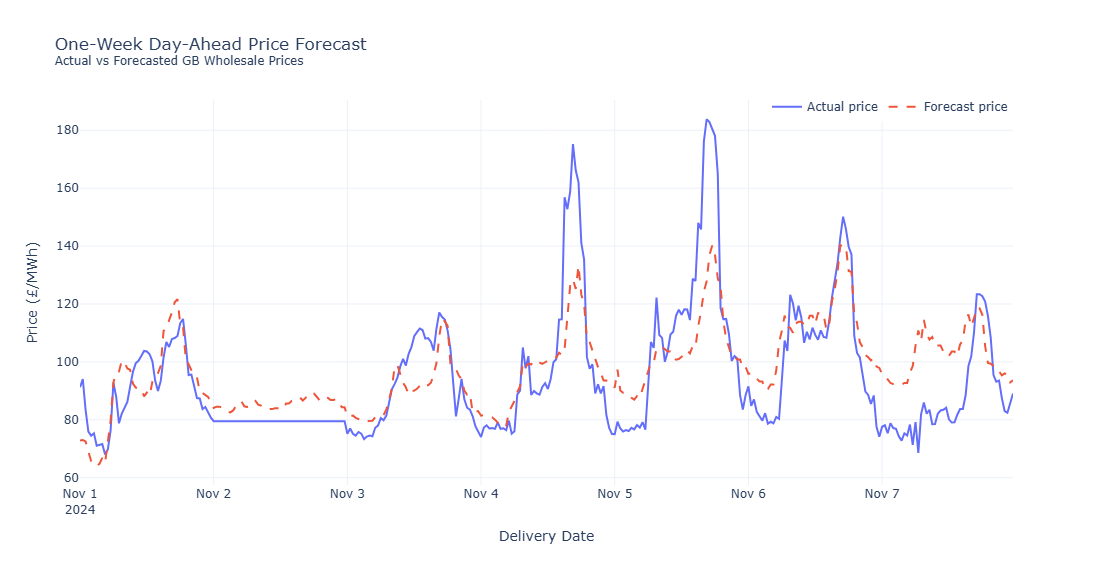

In [32]:
import os
import plotly.graph_objects as go
import plotly.express as px

os.makedirs("figures", exist_ok=True)

test["timestamp"] = pd.to_datetime(test["timestamp"])

# --------------------------------------------------
# 1. One-week Actual vs Forecast
# --------------------------------------------------

week = test[
    (test["timestamp"] >= "2024-11-01") &
    (test["timestamp"] < "2024-11-08")
].copy()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=week["timestamp"],
    y=week["price"],
    mode="lines",
    name="Actual price",
    line=dict(width=2),
    hovertemplate="Time: %{x}<br>Actual: £%{y:.2f}/MWh<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=week["timestamp"],
    y=week["predicted_price"],
    mode="lines",
    name="Forecast price",
    line=dict(width=2, dash="dash"),
    hovertemplate="Time: %{x}<br>Forecast: £%{y:.2f}/MWh<extra></extra>"
))

fig.update_layout(
    title="One-Week Day-Ahead Price Forecast<br><sup>Actual vs Forecasted GB Wholesale Prices</sup>",
    xaxis_title="Delivery Date",
    yaxis_title="Price (£/MWh)",
    template="plotly_white",
    width=1200,
    height=550,
    hovermode="x unified",
    legend=dict(orientation="h", y=1.02, x=1, xanchor="right")
)

fig.write_html("figures/actual_vs_forecast_week.html")
fig.write_image("figures/actual_vs_forecast_week.png", scale=3)
fig.show()





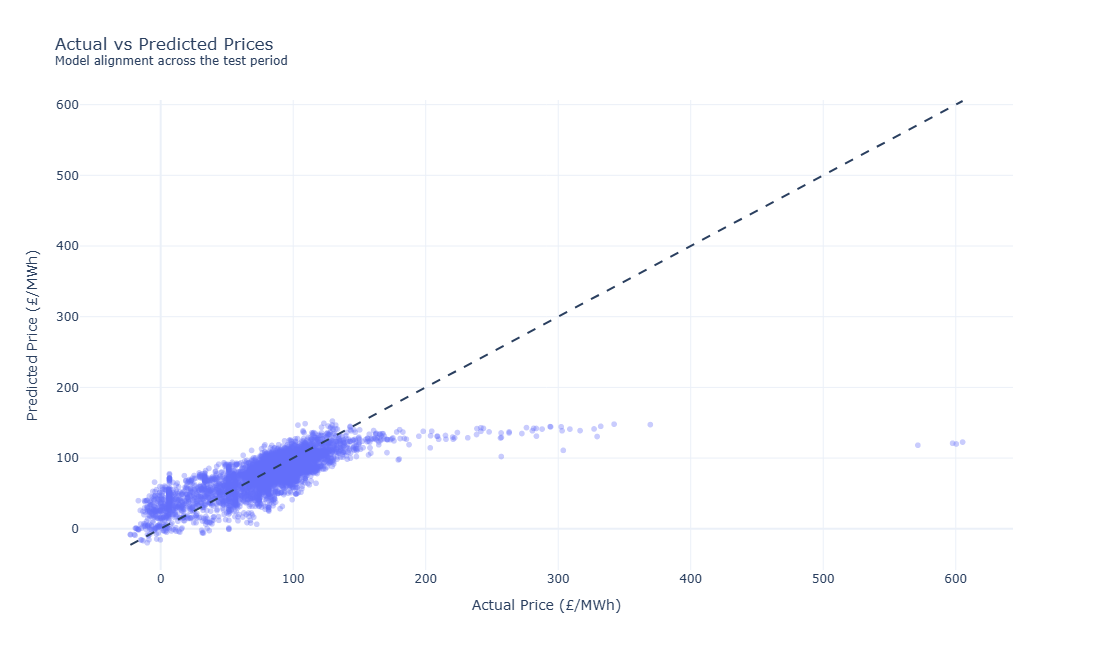

In [33]:
# --------------------------------------------------
# 2. Actual vs Predicted Scatter Plot
# --------------------------------------------------

fig = px.scatter(
    test,
    x="price",
    y="predicted_price",
    opacity=0.35,
    labels={
        "price": "Actual Price (£/MWh)",
        "predicted_price": "Predicted Price (£/MWh)"
    },
    title="Actual vs Predicted Prices<br><sup>Model alignment across the test period</sup>"
)

min_val = min(test["price"].min(), test["predicted_price"].min())
max_val = max(test["price"].max(), test["predicted_price"].max())

fig.add_shape(
    type="line",
    x0=min_val,
    y0=min_val,
    x1=max_val,
    y1=max_val,
    line=dict(dash="dash")
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=650
)

fig.write_html("figures/actual_vs_predicted_scatter.html")
fig.write_image("figures/actual_vs_predicted_scatter.png", scale=3)
fig.show()



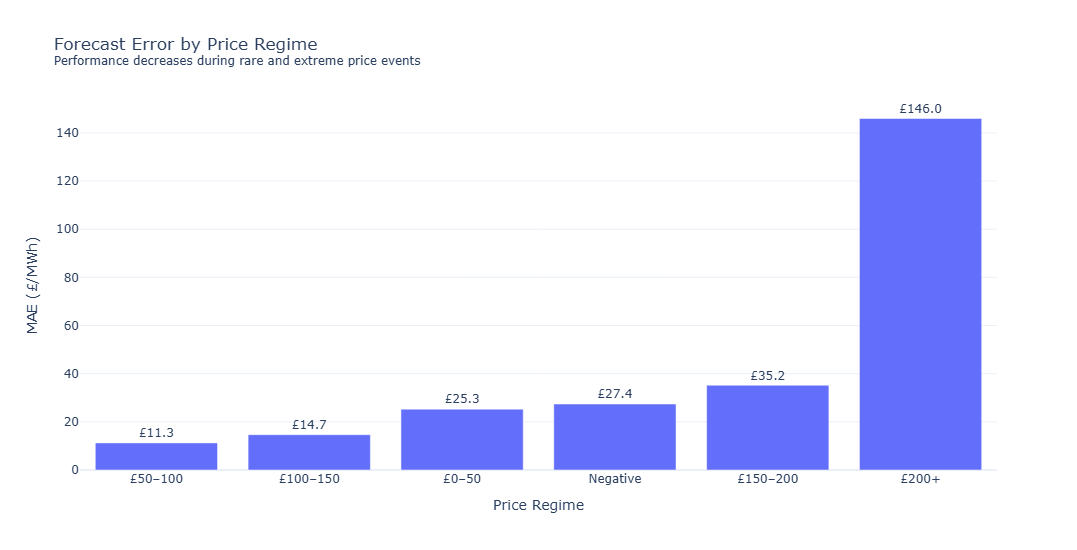

In [35]:
# --------------------------------------------------
# 3. Error by Price Regime
# --------------------------------------------------

regime_error = pd.DataFrame({
    "Price Range": ["£50–100", "£100–150", "£0–50", "Negative", "£150–200", "£200+"],
    "MAE": [11.26, 14.66, 25.27, 27.39, 35.20, 145.97],
    "Share of Test Set (%)": [63.0, 22.0, 11.0, 2.0, 0.8, 0.7]
})

fig = px.bar(
    regime_error,
    x="Price Range",
    y="MAE",
    text="MAE",
    labels={
        "MAE": "MAE (£/MWh)",
        "Price Range": "Price Regime"
    },
    title="Forecast Error by Price Regime<br><sup>Performance decreases during rare and extreme price events</sup>"
)

fig.update_traces(
    texttemplate="£%{text:.1f}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=550,
    yaxis_title="MAE (£/MWh)"
)

fig.write_html("figures/error_by_price_regime.html")
fig.write_image("figures/error_by_price_regime.png", scale=3)
fig.show()

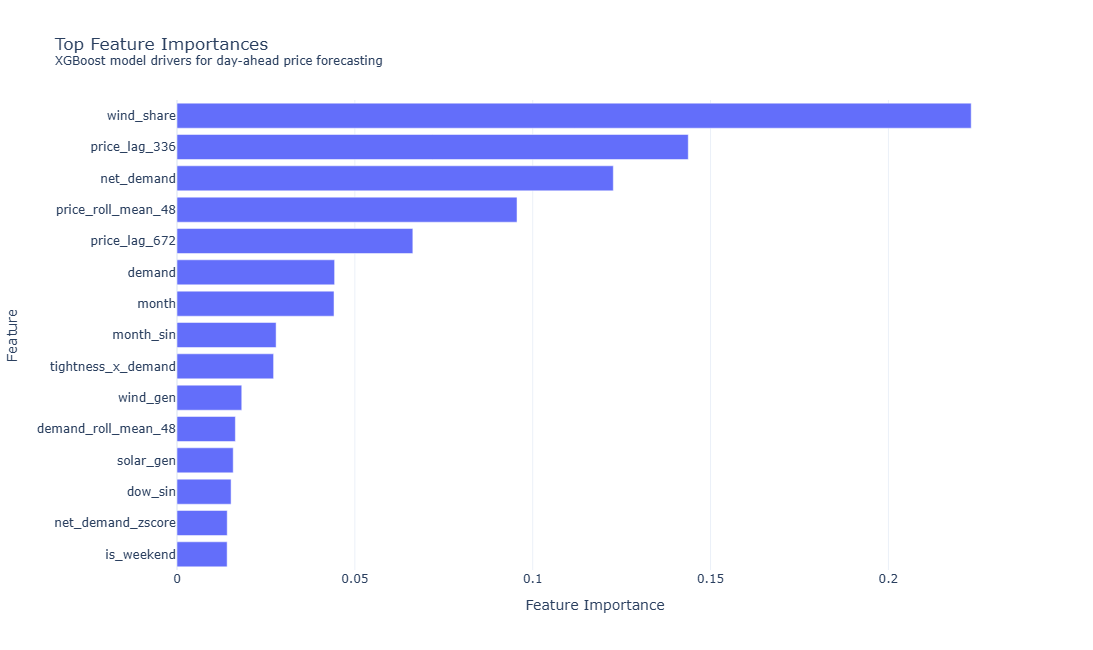

In [36]:
# --------------------------------------------------
# 4. Feature Importance
# --------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

fig = px.bar(
    importance_df.sort_values("Importance"),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top Feature Importances<br><sup>XGBoost model drivers for day-ahead price forecasting</sup>",
    labels={
        "Importance": "Feature Importance",
        "Feature": "Feature"
    }
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=650
)

fig.write_html("figures/feature_importance.html")
fig.write_image("figures/feature_importance.png", scale=3)
fig.show()